# Hydrogen Long — Investment Thesis

**Tickers:** NEL ASA (NEL.OL) · Air Liquide (AI.PA) · Linde (LIN)  
**Period:** 2020–2026 | **Data Source:** Yahoo Finance via yfinance | **Stack:** Python · Polars · Matplotlib

---

## Context

The hydrogen sector sits at the intersection of long-term decarbonization potential and near-term capital market disappointment. This analysis examines three equities across the hydrogen value chain — from pure-play technology (NEL) to established industrial gas majors (Air Liquide, Linde) — across three independent analytical layers:

1. **Performance Analytics** — How have the stocks performed historically?
2. **Fundamental Valuation** — Do the fundamentals justify current valuations?
3. **Forward-Looking Indicators** — What is the market pricing in?

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
DATA_DIR = Path("../../01_market_microstructure/data/thesis")
prices = pl.read_parquet(DATA_DIR / "prices.parquet")

## Setup

Price data is loaded from the central data store (`prices.parquet`), populated via `00_data_pipeline.ipynb`. All computations use **Polars** — a Rust-based DataFrame library significantly faster than pandas for analytical workloads.

In [3]:
prices

date,ticker,close
datetime[ms],str,f64
2020-12-09 00:00:00,"""AI""",92.489998
2020-12-10 00:00:00,"""AI""",130.0
2020-12-11 00:00:00,"""AI""",119.580002
2020-12-14 00:00:00,"""AI""",102.360001
2020-12-15 00:00:00,"""AI""",102.0
…,…,…
2026-02-20 00:00:00,"""PLTR""",135.240005
2026-02-23 00:00:00,"""PLTR""",130.600006
2026-02-24 00:00:00,"""PLTR""",128.839996


## Layer 1 — Performance Analytics

Objective: Quantify the historical return and risk profile of each stock.

Daily returns (`pct_change`) are computed per ticker, then used to derive cumulative returns and annualized metrics:

- **Annualized Return:** Geometric mean of daily returns × 252 trading days
- **Annualized Volatility:** Standard deviation of daily returns × √252
- **Sharpe Ratio:** `(Ann. Return − Risk-Free Rate) / Ann. Volatility` — measures risk-adjusted return (RF = 3%)
- **Max Drawdown:** Largest peak-to-trough decline — key input for risk management

In [1]:
H2_TICKERS = ["NEL.OL", "AI.PA", "LIN"]

h2 = prices.filter(pl.col("ticker").is_in(H2_TICKERS))

NameError: name 'prices' is not defined

In [5]:
h2 = (
    h2
    .sort(["ticker", "date"])
    .with_columns([
        pl.col("close")
          .pct_change()
          .over("ticker")        # pct_change() pro Ticker separat
          .alias("daily_return")
    ])
    .drop_nulls()
)

h2.head(8)


date,ticker,close,daily_return
datetime[ms],str,f64,f64
2020-01-03 00:00:00,"""AI.PA""",93.157387,-0.003157
2020-01-06 00:00:00,"""AI.PA""",92.530434,-0.00673
2020-01-07 00:00:00,"""AI.PA""",92.124763,-0.004384
2020-01-08 00:00:00,"""AI.PA""",92.198524,0.000801
2020-01-09 00:00:00,"""AI.PA""",92.567314,0.004
2020-01-10 00:00:00,"""AI.PA""",92.788582,0.00239
2020-01-13 00:00:00,"""AI.PA""",93.120506,0.003577
2020-01-14 00:00:00,"""AI.PA""",93.673691,0.005941


In [6]:
h2_cum = (
    h2
    .with_columns([
        (1 + pl.col("daily_return"))
          .cum_prod()
          .over("ticker")
          .alias("cum_return")
    ])
)


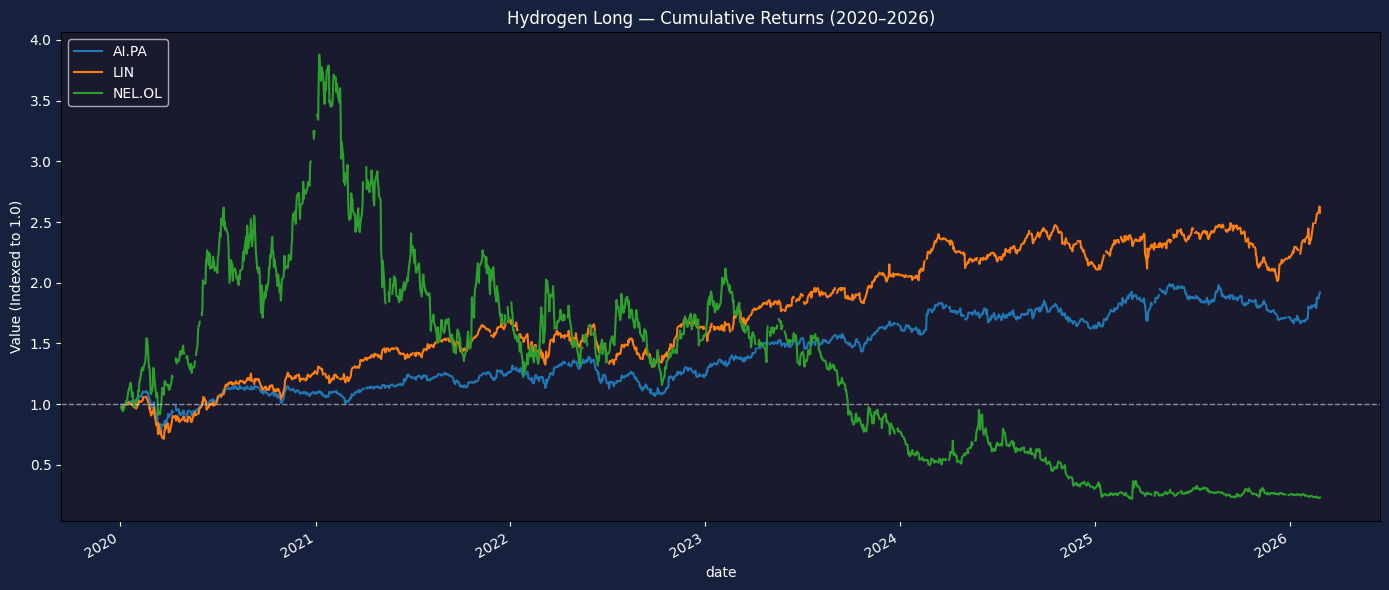

In [7]:
wide = (
    h2_cum
    .select(["date", "ticker", "cum_return"])
    .pivot(index="date", on="ticker", values="cum_return")
    .sort("date")
)

df_plot = wide.to_pandas().set_index("date")

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#16213e")
ax.set_facecolor("#1a1a2e")

df_plot.plot(ax=ax)
ax.axhline(1.0, color="white", linestyle="--", linewidth=1, alpha=0.5)
ax.set_title("Hydrogen Long — Cumulative Returns (2020–2026)", color="white")
ax.set_ylabel("Value (Indexed to 1.0)", color="white")
ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.legend(loc="upper left", facecolor="#1a1a2e", labelcolor="white")
plt.tight_layout()
plt.show()

### Risk/Return Metrics

Annualized metrics and max drawdown computed simultaneously across all tickers via `group_by().agg()`.

In [8]:
RF = 0.03
TRADING_DAYS = 252

metrics = (
    h2
    .group_by("ticker")
    .agg([
        # Annualized Return
        ((1 + pl.col("daily_return")).product() 
            ** (TRADING_DAYS / pl.col("daily_return").count()) - 1
        ).alias("ann_return"),

        (pl.col("daily_return").std() * np.sqrt(TRADING_DAYS)).alias("ann_volatility"),
    ])
    .with_columns([
        ((pl.col("ann_return") - RF) / pl.col("ann_volatility")).alias("sharpe"),
    ])
    .sort("ticker")
)

metrics

ticker,ann_return,ann_volatility,sharpe
str,f64,f64,f64
"""AI.PA""",0.109937,0.209046,0.382389
"""LIN""",0.167018,0.248065,0.55235
"""NEL.OL""",-0.212737,0.695349,-0.349087


In [9]:
max_dd = (
    h2_cum
    .with_columns([
        pl.col("cum_return")
          .cum_max()
          .over("ticker")
          .alias("rolling_max")
    ])
    .with_columns([
        ((pl.col("cum_return") - pl.col("rolling_max")) / pl.col("rolling_max"))
          .alias("drawdown")
    ])
    .group_by("ticker")
    .agg(pl.col("drawdown").min().alias("max_drawdown"))
)

max_dd


ticker,max_drawdown
str,f64
"""AI.PA""",-0.292801
"""LIN""",-0.325851
"""NEL.OL""",-0.943246


In [11]:
join = max_dd.join(metrics, on="ticker").sort("ticker")

In [12]:
join

ticker,max_drawdown,ann_return,ann_volatility,sharpe
str,f64,f64,f64,f64
"""AI.PA""",-0.292801,0.109937,0.209046,0.382389
"""LIN""",-0.325851,0.167018,0.248065,0.55235
"""NEL.OL""",-0.943246,-0.212737,0.695349,-0.349087


## Layer 2 — Fundamental Valuation

Objective: Assess valuation based on company fundamentals — independent of market price movements.

Fundamental data is sourced via `yfinance` from the `.info` dictionary and persisted to `fundamentals.parquet`. Key metrics:

| Metric | Definition |
|--------|-----------|
| **P/E (trailing/forward)** | Price-to-Earnings — how much does the market pay per $ of earnings? |
| **EV/EBITDA** | Enterprise value relative to operating profit — capital structure neutral |
| **Gross Margin** | Core business profitability — measures production efficiency |
| **Free Cash Flow** | Actual cash generated — more reliable than accounting earnings |
| **Revenue Growth** | Is the company growing? Does it justify the valuation? |

In [13]:
fundamentals = pl.read_parquet(DATA_DIR / "fundamentals.parquet")
h2_fund = fundamentals.filter(pl.col("ticker").is_in(H2_TICKERS))
h2_fund


ticker,market_cap,pe_trailing,pe_forward,ev_ebitda,price_to_book,revenue_growth,free_cashflow,gross_margin,operating_margin
str,i64,f64,f64,f64,f64,f64,i64,f64,f64
"""NEL.OL""",3723868672,null,-9.528737,-8.71,0.953861,-0.132,-154409744,0.63586,-2.54977
"""AI.PA""",101532942336,28.8,22.266554,14.334,3.866963,-0.034,1555575040,0.64175,0.19473
"""LIN""",236242960384,34.84689,26.166513,19.482,6.1809382,0.058,4786500096,0.48835,0.28172


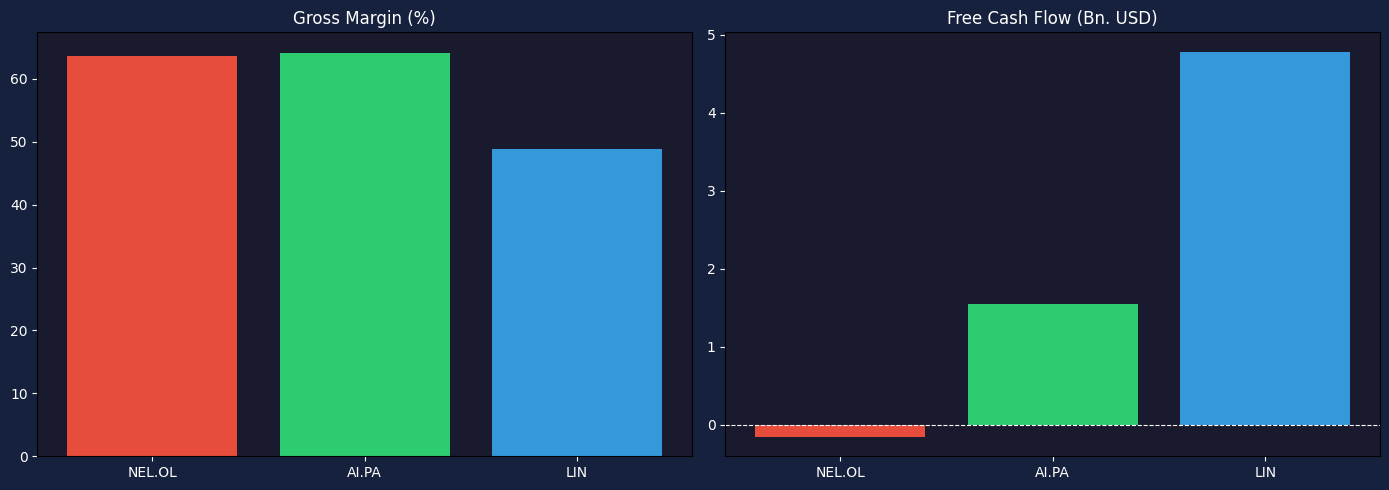

In [14]:
tickers    = h2_fund["ticker"].to_list()
gross_margins = (h2_fund["gross_margin"] * 100).to_list()
fcf_bn     = (h2_fund["free_cashflow"] / 1_000_000_000).to_list()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#16213e")

ax1 = axes[0]
ax1.bar(tickers, gross_margins, color=["#e74c3c", "#2ecc71", "#3498db"])
ax1.set_title("Gross Margin (%)", color="white")
ax1.set_facecolor("#1a1a2e")
ax1.tick_params(colors="white")

ax2 = axes[1]
ax2.bar(tickers, fcf_bn, color=["#e74c3c", "#2ecc71", "#3498db"])
ax2.set_title("Free Cash Flow (Bn. USD)", color="white")
ax2.set_facecolor("#1a1a2e")
ax2.tick_params(colors="white")
ax2.axhline(0, color="white", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.show()

## Layer 3 — Forward-Looking Indicators

Objective: Evaluate market expectations and the analyst consensus view.

Analyst data from `analysts.parquet` includes price targets (Low/Mean/High), consensus recommendations, and short interest. This layer serves as the **market sentiment check**: does the market confirm our thesis, or are we trading against consensus?

- **Price Target Upside/Downside:** `(Target − Current Price) / Current Price × 100`
- **Short Interest:** % of float currently sold short — high short interest signals market skepticism (or potential squeeze)

In [15]:
analysts = pl.read_parquet(DATA_DIR / "analysts.parquet")
h2_ana = analysts.filter(pl.col("ticker").is_in(H2_TICKERS))
print(h2_ana)


shape: (3, 7)
┌────────┬────────────────┬─────────────┬─────────────┬────────────┬──────────────┬────────────────┐
│ ticker ┆ recommendation ┆ target_mean ┆ target_high ┆ target_low ┆ num_analysts ┆ short_interest │
│ ---    ┆ ---            ┆ ---         ┆ ---         ┆ ---        ┆ ---          ┆ ---            │
│ str    ┆ str            ┆ f64         ┆ f64         ┆ f64        ┆ i64          ┆ f64            │
╞════════╪════════════════╪═════════════╪═════════════╪════════════╪══════════════╪════════════════╡
│ NEL.OL ┆ underperform   ┆ 2.18333     ┆ 4.2         ┆ 1.0        ┆ 12           ┆ null           │
│ AI.PA  ┆ buy            ┆ 195.5238    ┆ 216.0       ┆ 154.0      ┆ 21           ┆ null           │
│ LIN    ┆ buy            ┆ 512.4308    ┆ 565.0       ┆ 381.0      ┆ 26           ┆ 0.0131         │
└────────┴────────────────┴─────────────┴─────────────┴────────────┴──────────────┴────────────────┘


In [16]:
current_prices = (
    prices.filter(pl.col("ticker").is_in(H2_TICKERS))
    .sort("date")
    .group_by("ticker")
    .agg(pl.col("close").last().alias("current_price"))
)

h2_full = h2_ana.join(current_prices, on="ticker").sort("ticker")
print(h2_full.select(["ticker", "current_price", "target_low", "target_mean", "target_high", "recommendation"]))


shape: (3, 6)
┌────────┬───────────────┬────────────┬─────────────┬─────────────┬────────────────┐
│ ticker ┆ current_price ┆ target_low ┆ target_mean ┆ target_high ┆ recommendation │
│ ---    ┆ ---           ┆ ---        ┆ ---         ┆ ---         ┆ ---            │
│ str    ┆ f64           ┆ f64        ┆ f64         ┆ f64         ┆ str            │
╞════════╪═══════════════╪════════════╪═════════════╪═════════════╪════════════════╡
│ AI.PA  ┆ 179.5         ┆ 154.0      ┆ 195.5238    ┆ 216.0       ┆ buy            │
│ LIN    ┆ 498.51001     ┆ 381.0      ┆ 512.4308    ┆ 565.0       ┆ buy            │
│ NEL.OL ┆ 2.052         ┆ 1.0        ┆ 2.18333     ┆ 4.2         ┆ underperform   │
└────────┴───────────────┴────────────┴─────────────┴─────────────┴────────────────┘


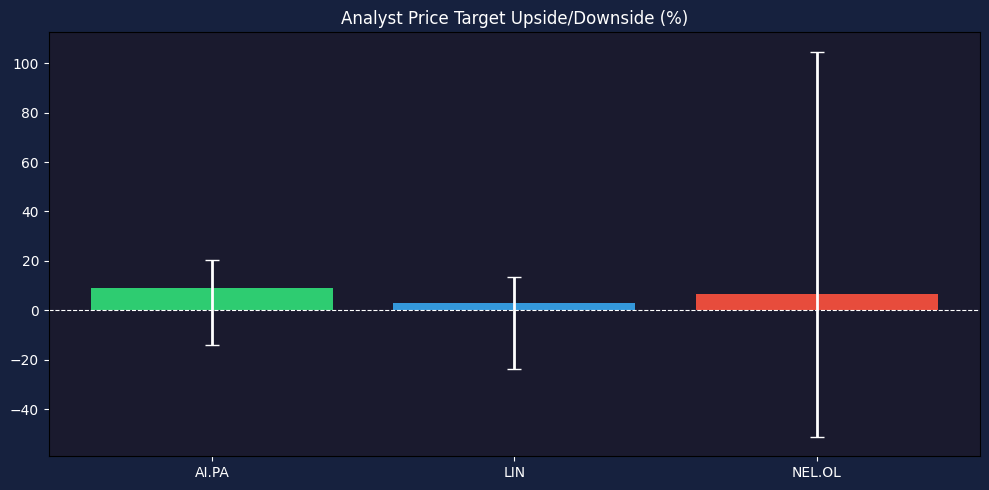

In [17]:
tickers_s = h2_full["ticker"].to_list()
current   = h2_full["current_price"].to_list()
t_mean    = h2_full["target_mean"].to_list()
t_high    = h2_full["target_high"].to_list()
t_low     = h2_full["target_low"].to_list()

upside_mean = [(m - c) / c * 100 for m, c in zip(t_mean, current)]
upside_high = [(h - c) / c * 100 for h, c in zip(t_high, current)]
upside_low  = [(l - c) / c * 100 for l, c in zip(t_low, current)]

errors_below = [upside_mean[i] - upside_low[i]  for i in range(len(tickers_s))]
errors_above = [upside_high[i] - upside_mean[i] for i in range(len(tickers_s))]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#16213e")
ax.set_facecolor("#1a1a2e")

colors = ["#2ecc71", "#3498db", "#e74c3c"]
ax.bar(tickers_s, upside_mean, color=colors, zorder=2)
ax.errorbar(tickers_s, upside_mean,
            yerr=[errors_below, errors_above],
            fmt="none", color="white", capsize=5, linewidth=2)

ax.axhline(0, color="white", linewidth=0.8, linestyle="--")
ax.set_title("Analyst Price Target Upside/Downside (%)", color="white")
ax.tick_params(colors="white")
ax.set_xticks(range(len(tickers_s)))
ax.set_xticklabels(tickers_s, color="white")
plt.tight_layout()
plt.show()

# Investment Summary — Hydrogen Long

## Thesis Overview

The structural case for green hydrogen in European industrial decarbonization is intact and accelerating. Green hydrogen is not an optional technology — it is the only viable pathway to decarbonize hard-to-abate industries like steel, ammonia, and aviation fuels, where direct electrification cannot substitute for fossil feedstocks. Europe's regulatory framework makes this a policy-enforced demand story, not a speculative one.

**Our position:** Long Air Liquide and Linde as core holdings. Speculative long NEL ASA as a high-conviction, high-risk bet on electrolyzer scale-up.

---

## Why Air Liquide and Linde Now

Both companies combine the structural upside of green hydrogen demand with proven profitability, strong free cash flow, and investment-grade balance sheets. Air Liquide (Sharpe: 0.38, FCF: +€1.56bn) and Linde (Sharpe: 0.55, FCF: +$4.79bn) are positioned to capture infrastructure buildout spending across Europe without the binary execution risk of pure-play startups. Analyst consensus is Buy on both names, with 9% and 3% upside to price targets respectively.

## Why NEL ASA — And Why It's a Risk

NEL's gross margin of 63.6% — nearly identical to Air Liquide — confirms the technology works. The problem is scaling. NEL remains free cash flow negative (−$154M), revenues declined 13% in FY2025, and the company has yet to convert its pipeline into recurring revenue. This is a binary bet: if European hydrogen infrastructure buildout accelerates as policy dictates, NEL is the pick-and-shovel play with the most operating leverage. If project FIDs continue to be delayed, the stock has further downside from already distressed levels.

---

## Upcoming Catalysts

### EU Hydrogen Strategy Revision — Q2 2026
The European Commission launches a formal consultation in Q2 2026 to revise its hydrogen targets and redirect funding toward priority end-use sectors. New binding mandates or stronger enforcement of RED III quotas would be a direct positive catalyst for NEL's order book and Air Liquide's infrastructure pipeline.

### ENNOH Operational Launch — August 2026
The EU's new hydrogen network operator (ENNOH) must be formally established by August 5, 2026, following national transposition of the Gas Directive. Once live, ENNOH publishes the first ten-year hydrogen network development plan — the clearest signal yet of where infrastructure capital will flow. This is the event that turns regulatory commitments into bankable project pipelines.

### €5.2bn EU Innovation Fund — Grant Agreements H1 2026
61 net-zero projects, including hydrogen infrastructure, are set to sign EU grant agreements in H1 2026 and begin implementation. For NEL specifically, up to €135M in approved EU funding supports the industrialization of its next-generation pressurized alkaline electrolyzer at Herøya, with a target capacity of 4 GW annually. Board approval was granted in December 2025. Execution in 2026 is the proof point.

### NEL Order Intake Recovery
NEL's Q3 2025 order intake collapsed 64% YoY to just 57M NOK — the most critical near-term risk to the bull case. In November 2025, NEL secured a $50M+ PEM contract for a 40 MW Norwegian hydrogen project — a partial recovery signal. Watch Q1 2026 order intake as the leading indicator: sustained orders above 200M NOK per quarter would confirm the commercial inflection. Failure to recover would invalidate the NEL position.

### Green Steel Demand — Structural, Not Cyclical
Samsung E&A's strategic stake in NEL and a confirmed $7M PEM order for a US steel mill in 2025 demonstrate that the steel industry is beginning to act, not just plan. Europe's 9,040 km Wasserstoff-Kernnetz (backed by a €24bn KfW loan approved November 2024) is designed to connect industrial hydrogen consumers — steel, chemicals, aviation — to supply. As this infrastructure becomes operational through 2026–2028, green hydrogen transitions from subsidy-dependent to economically rational. That is when NEL's order book inflects.

---

*Research compiled March 2026 — Raphael Zimmermann*